# Compare RNA expression and GeneActivityScore across cell-types

In [ ]:
here::i_am("revision/blood_trajectory/01_subset_cells.ipynb")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [2]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

## RNA pseudobulking per celltype

In [7]:
io$RNA_sce = file.path(io$basedir, '/results/rna/pseudobulk/celltype/SingleCellExperiment_pseudobulk.rds')
io$ATAC_sce = file.path(io$basedir, '/data/processed/atac/archR/Matrices/GeneScoreMatrix_distal_summarized_experiment.rds')
io$markers =  file.path(io$basedir, '/results/rna/differential/pseudobulk/celltype/parsed/marker_genes_filtered.txt.gz')

In [9]:
markers = fread(io$markers)

In [5]:
# Load RNA
sceRNA = readRDS(io$RNA_sce)
rna.mtx = sceRNA@assays@data$logcounts

In [10]:
# load ATAC
sceATAC = readRDS(io$ATAC_sce)

In [11]:
sceATAC$celltype.mapped

class: SummarizedExperiment 
dim: 24333 45887 
metadata(0):
assays(1): GeneScoreMatrix_distal
rownames(24333): Xkr4 Rp1 ... 4933400A11Rik Asmt
rowData names(6): seqnames start ... name idx
colnames(45887): E8.5_rep1#GGCTGAGAGCTTAACA-1
  E8.5_rep1#AGTAACACAACACTTG-1 ... E7.75_rep1#GCTAAGAAGTTGCCTC-1
  E7.75_rep1#AGTCGCATCGTTACTT-1
colData names(35): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [14]:
assayNames(sceATAC) <- "counts"

In [15]:
# aggregate mean of GeneScoreMatrix per mapped celltype
gene_counts_pseudobulk <- aggregateAcrossCells(sceATAC, id=sceATAC$celltype.mapped, statistics = 'mean', BPPARAM = BPPARAM)

In [16]:
# extract matrix
atac.mtx = gene_counts_pseudobulk@assays@data$counts
rownames(atac.mtx) = rowData(gene_counts_pseudobulk)$name

In [51]:
# Define function to correlate RNA - ATAC
corr_gene = function(gene, method='pearson', log2_atac=FALSE){ # log2 doesn't make a difference for spearman 
    if(log2_atac==TRUE){
        tmp = cor(rna.mtx[gene,], log2(atac.mtx[gene,]+1), method=method)
    }else{tmp = suppressMessages(cor(rna.mtx[gene,], atac.mtx[gene,], method=method))}
    return(tmp)
}

In [60]:
head(markers)

celltype,gene,score
<chr>,<chr>,<dbl>
Epiblast,Acsl4,1
Epiblast,Cdh9,1
Epiblast,Chd9,1
Epiblast,Dnajc6,1
Epiblast,Far2,1
Epiblast,Fut9,1


In [65]:
# Plot mean of celltype markers_tmp
options(repr.plot.width=25, repr.plot.height=5)

p = lapply(unique(markers$celltype), function(x){
        markers_tmp = markers[celltype==x] %>% 
            .[order(-score), gene] %>% head(50)
        markers_tmp = Reduce(intersect, list(markers_tmp, rownames(atac.mtx), rownames(rna.mtx)))

        if(length(markers_tmp)>1){
            rna.tmp = data.table(celltype = colnames(rna.mtx), rna_counts = colMeans(rna.mtx[markers_tmp,]))
            atac.tmp =  data.table(celltype = colnames(atac.mtx), atac_counts = colMeans(atac.mtx[markers_tmp,]))

            merge = merge(rna.tmp, atac.tmp, by='celltype') %>%
                .[,`:=`(rna_counts = scale(rna_counts),
                        atac_counts = scale(atac_counts))]

    #        options(repr.plot.width=6, repr.plot.height=6)
            
            lm = lm(rna_counts ~ atac_counts, merge)

            ggplot(merge, aes(rna_counts, atac_counts)) + 
                geom_smooth(method='lm', col='black', alpha=0.5) + 
                geom_point(size=4, aes(col=celltype)) + 
            #    geom_abline(slope=1) + 
                scale_colour_manual(values=opts$celltype.colors) + 
                ggrepel::geom_text_repel(data=unique(rbind(head(merge[order(-rna_counts)], 5), head(merge[order(-atac_counts)], 5))), # label top 5 of atac & rna
                                         aes(label=celltype),
                                         box.padding=0.8) + 
                ggtitle(x,
                       paste('Corr:', round(cor(merge$rna_counts, merge$atac_counts, method='pearson'),2), 
                             '/ R2:', round(summary(lm)$r.squared,2), 
                             '/ number of genes =', length(markers_tmp))) + 
                xlab('gene expression') + ylab('gene accessibility') + 
                theme_bw() +
                theme(legend.position='none',
                      text=element_text(size=15, color='black'),
                      axis.text=element_text(color='black'))
    }
})

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


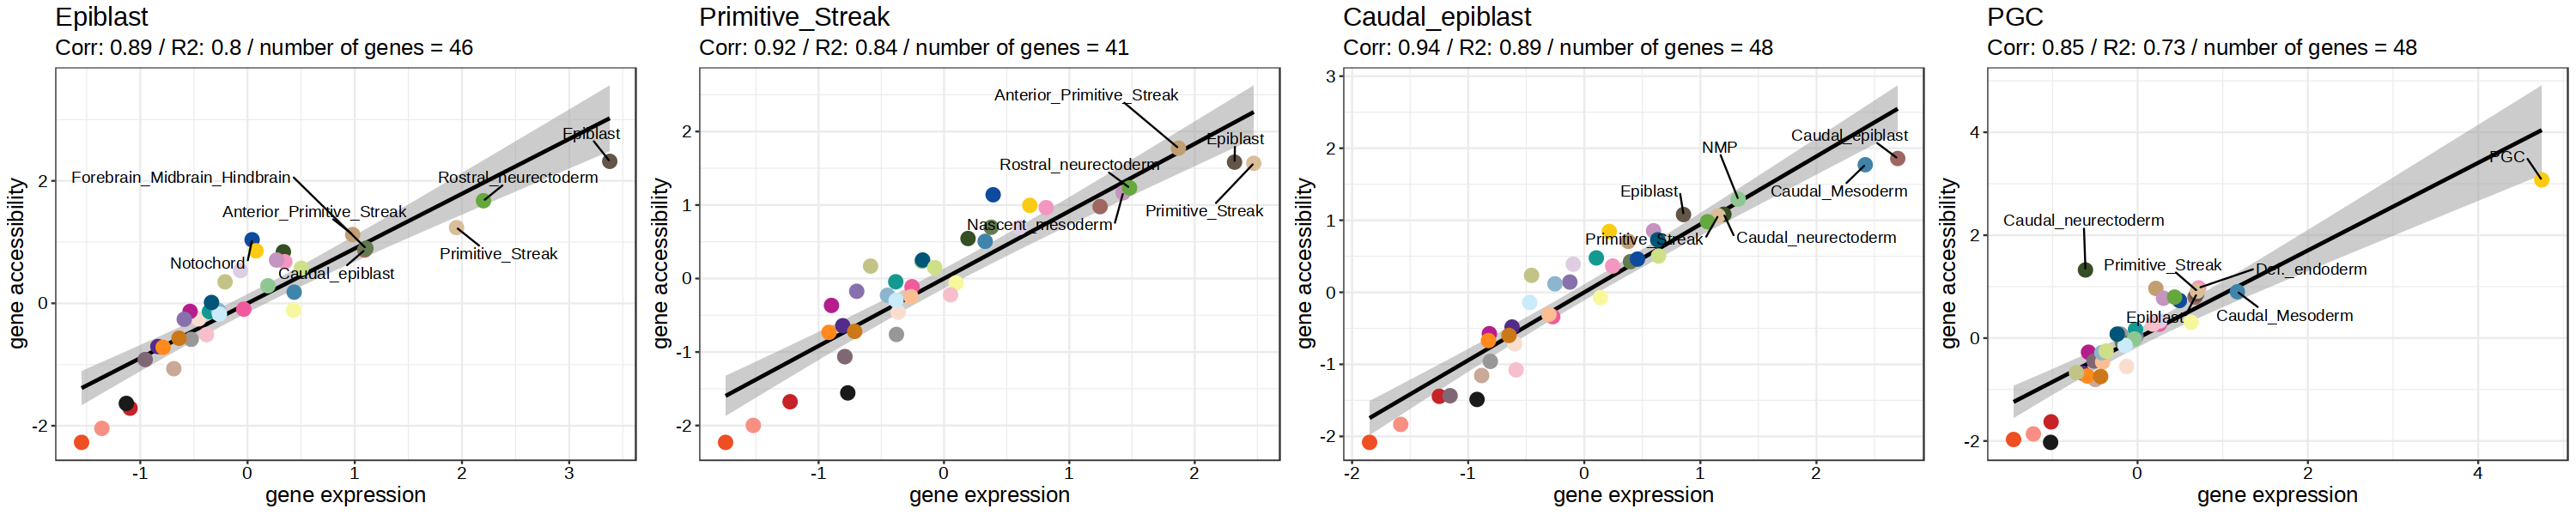

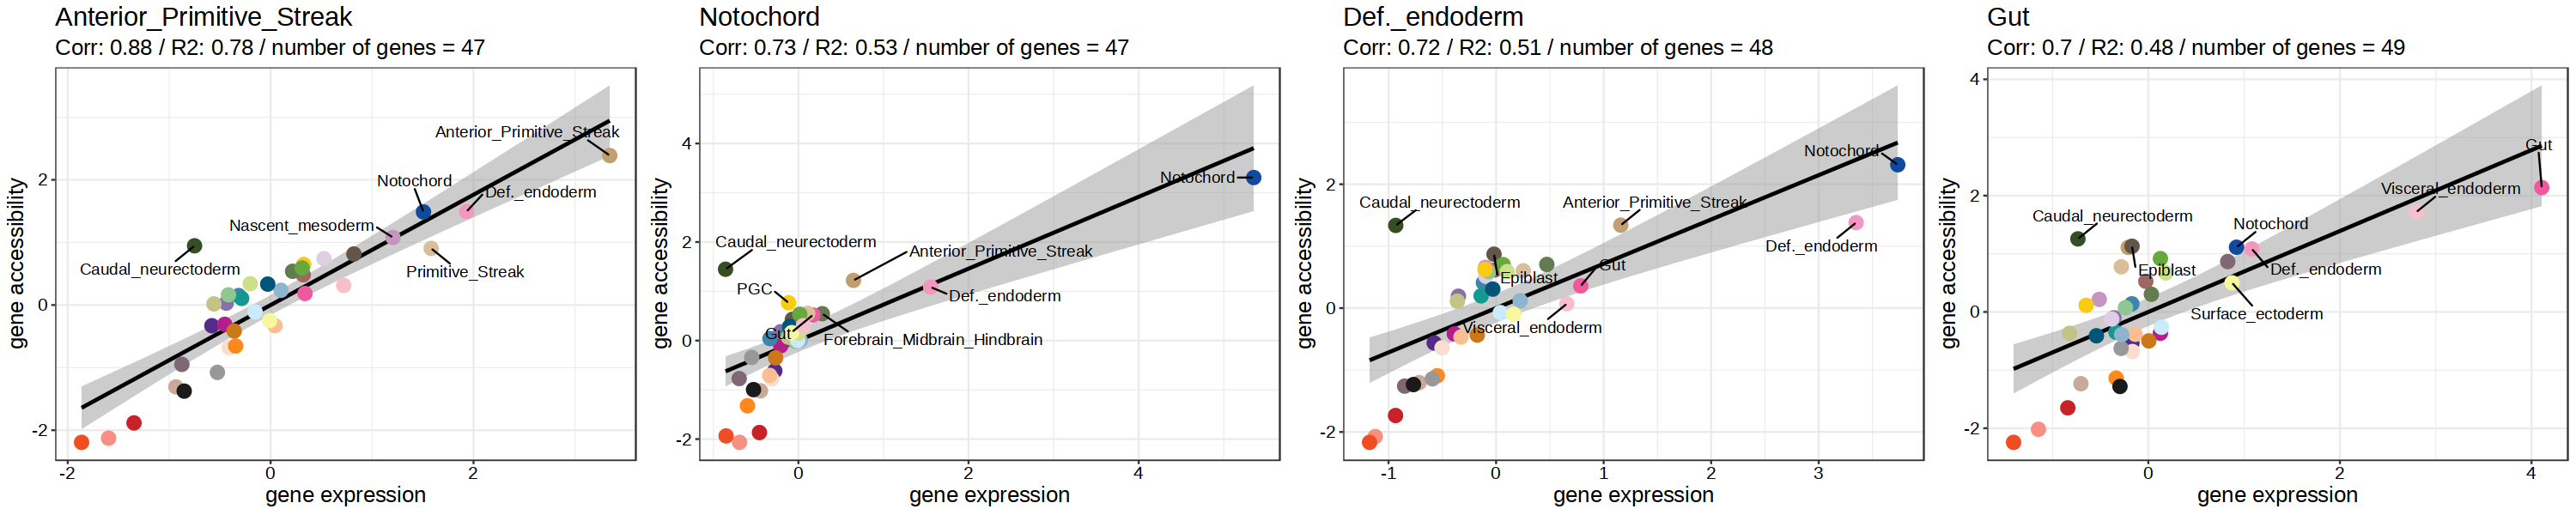

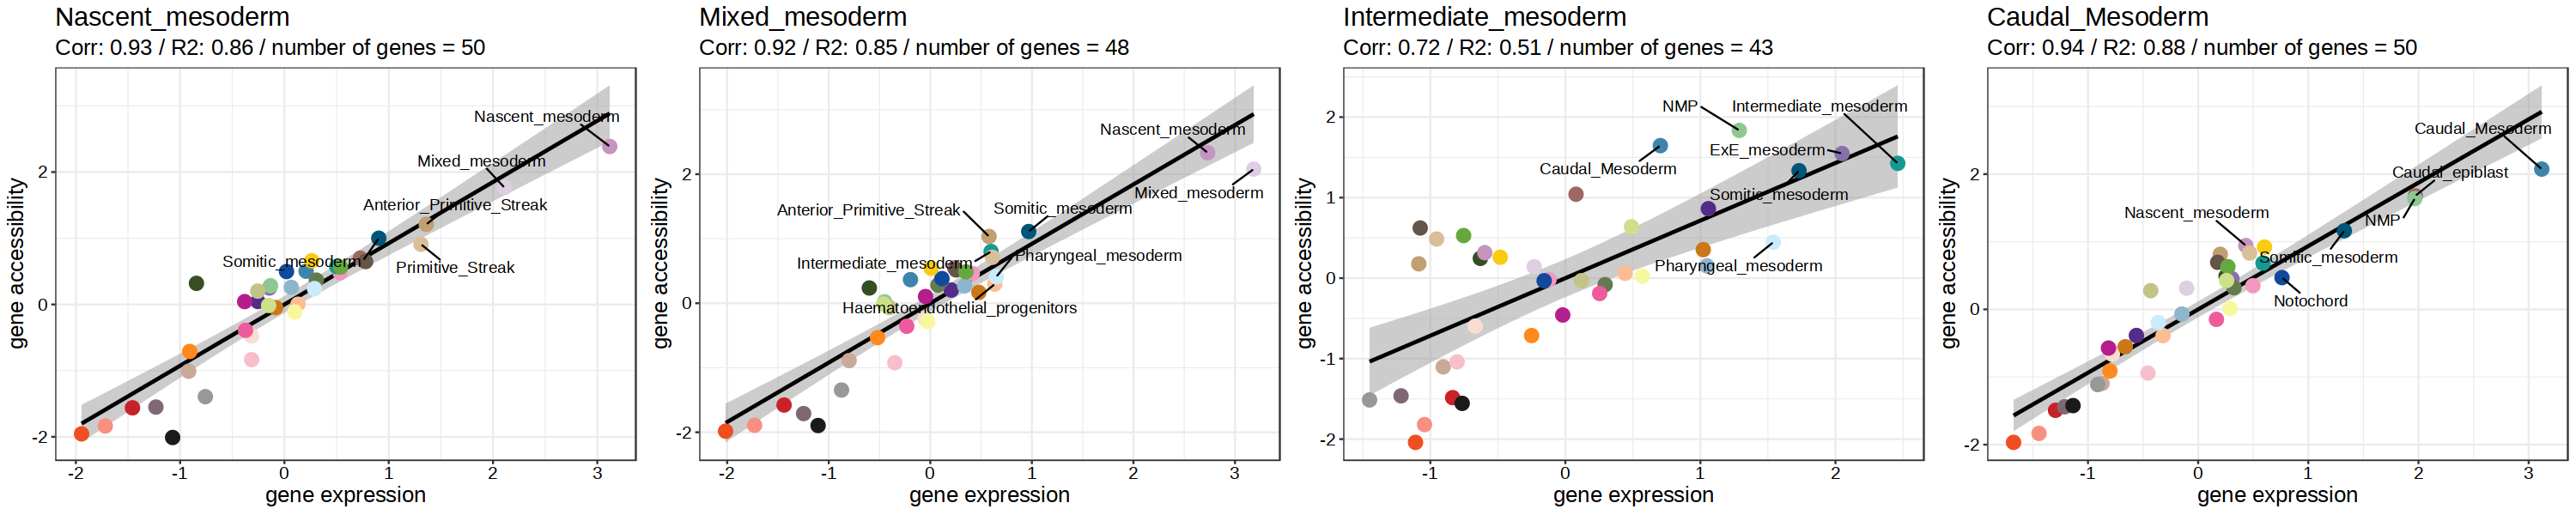

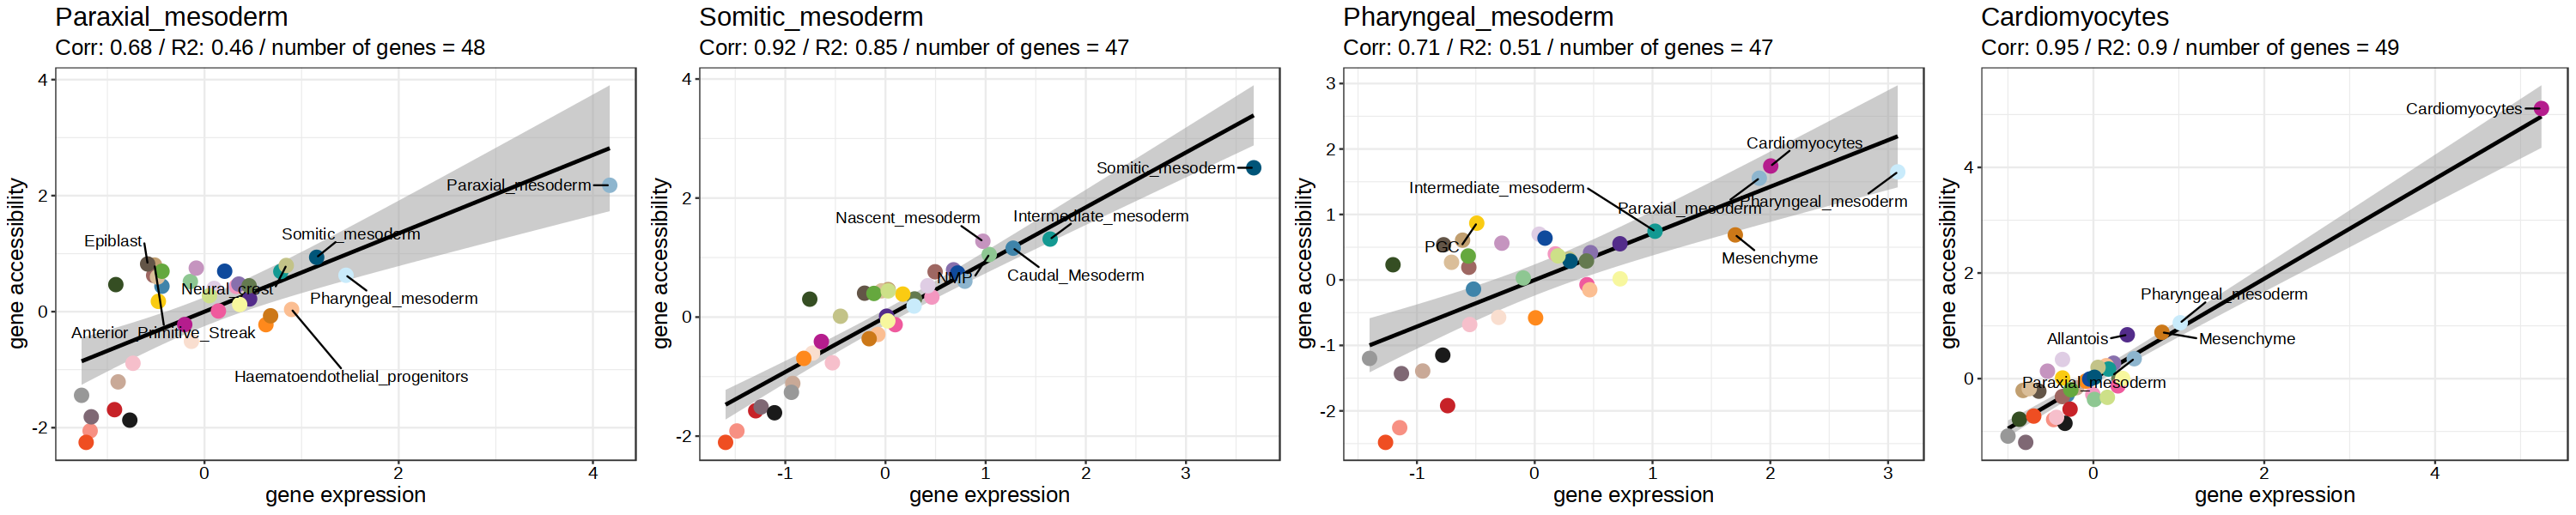

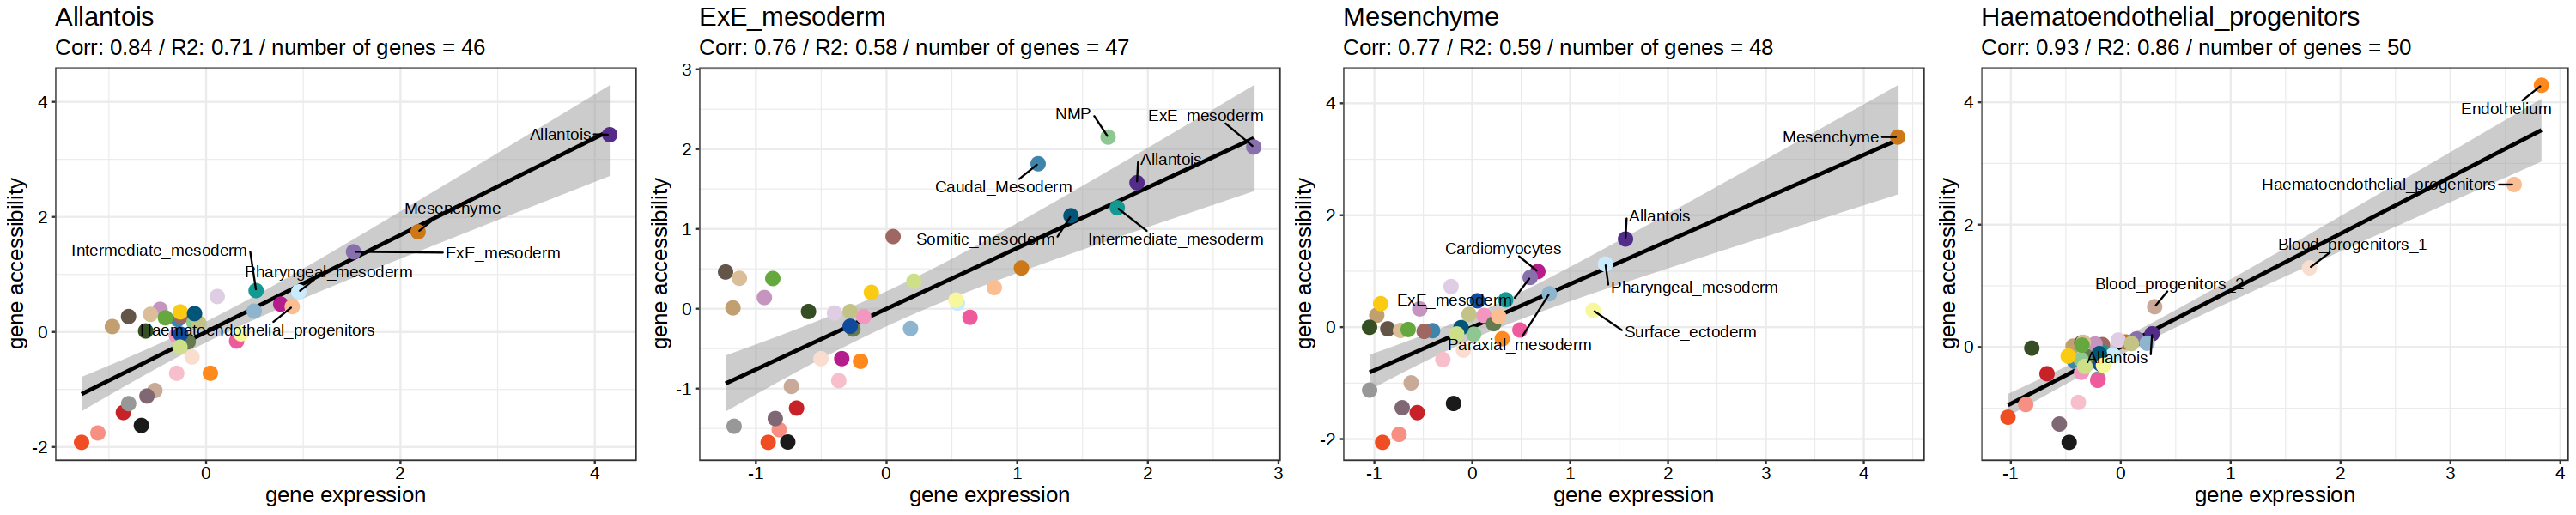

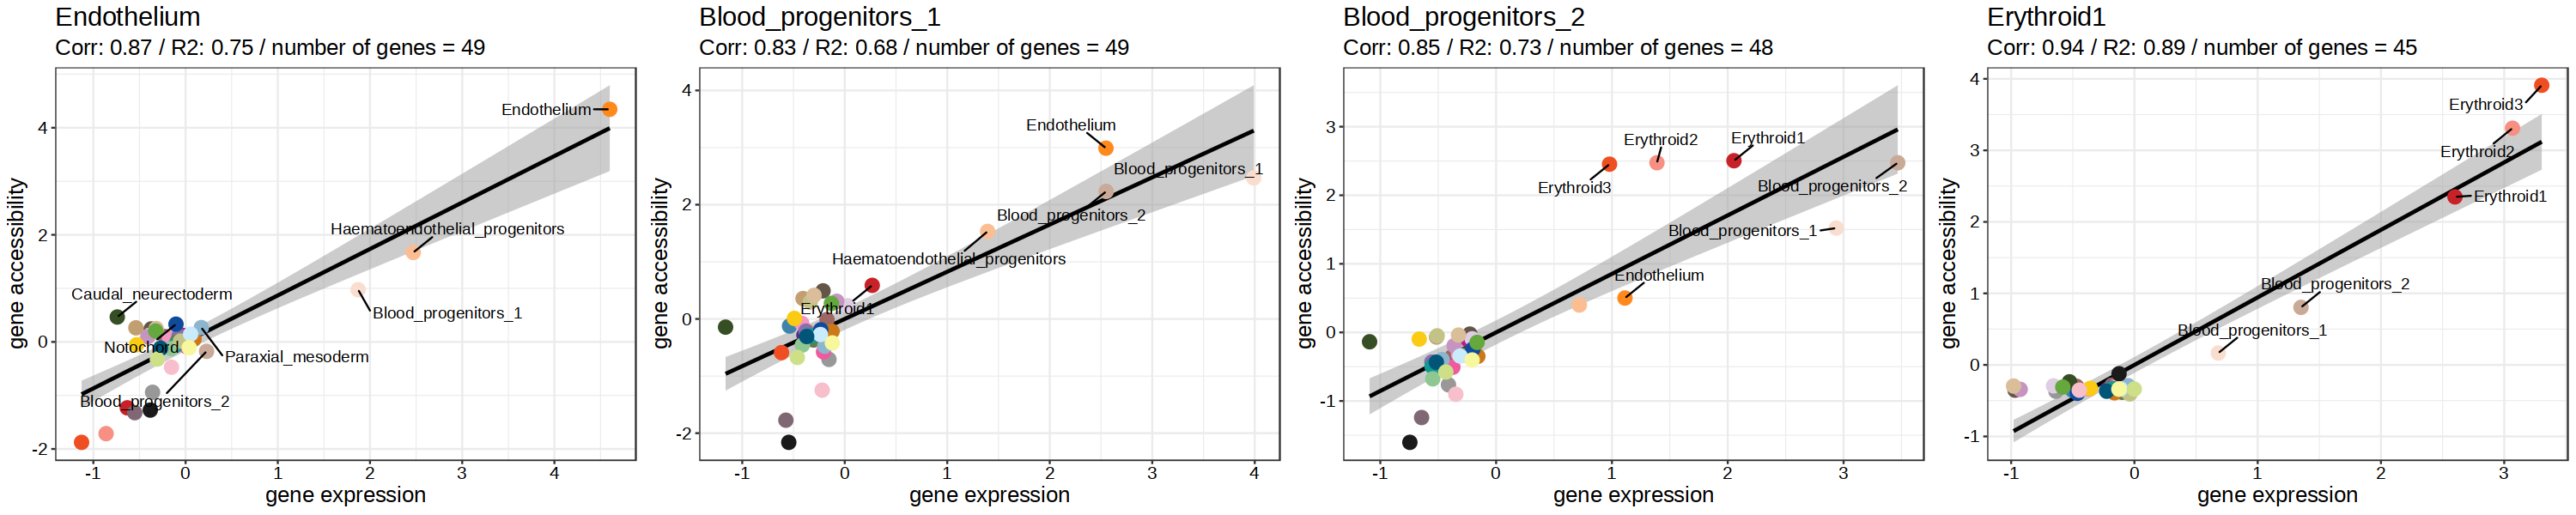

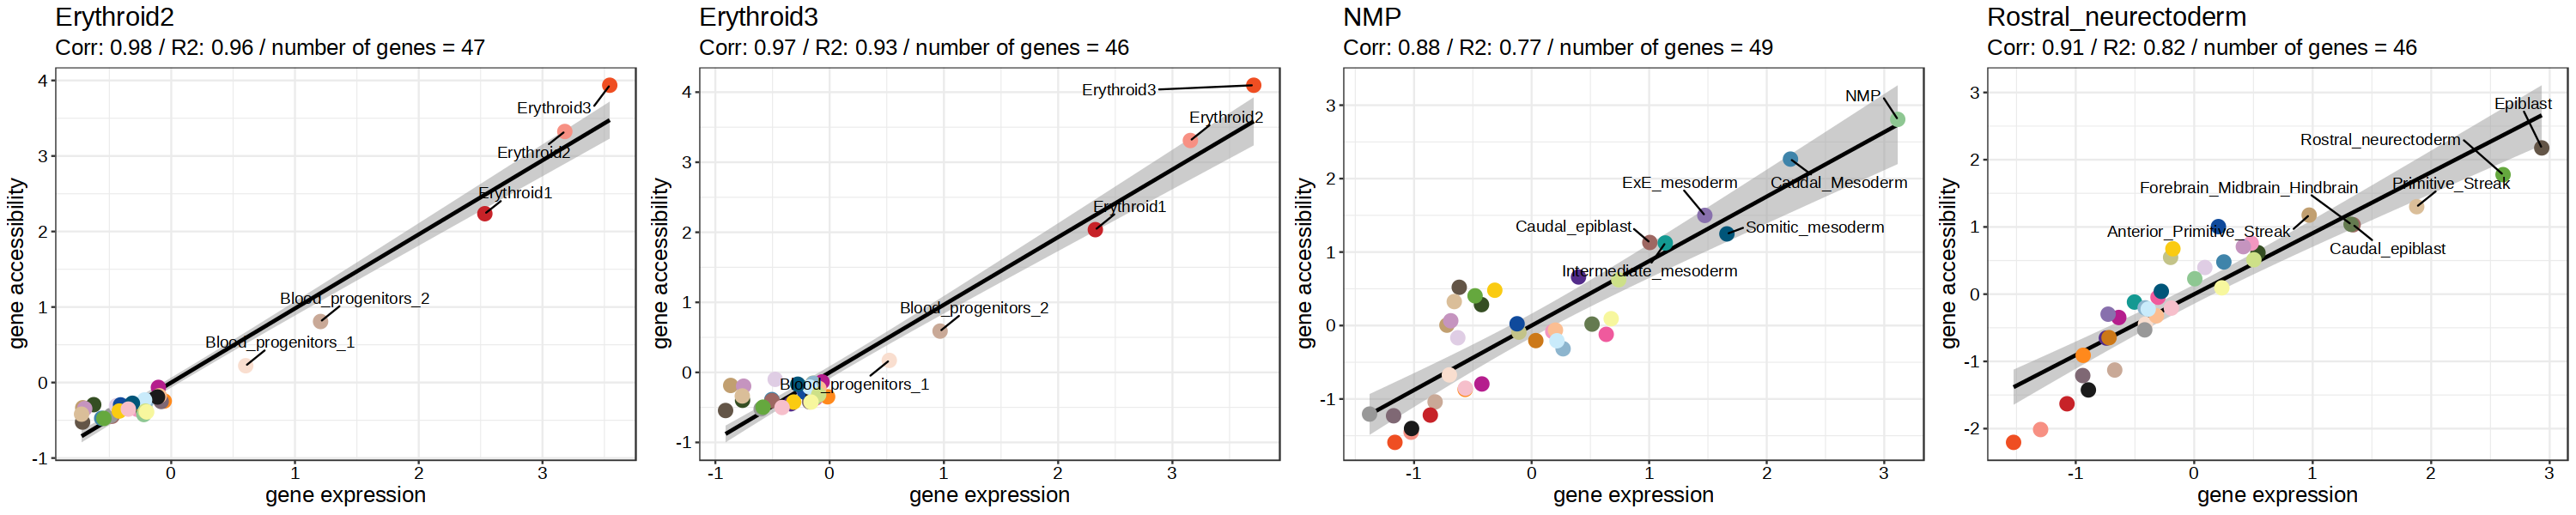

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


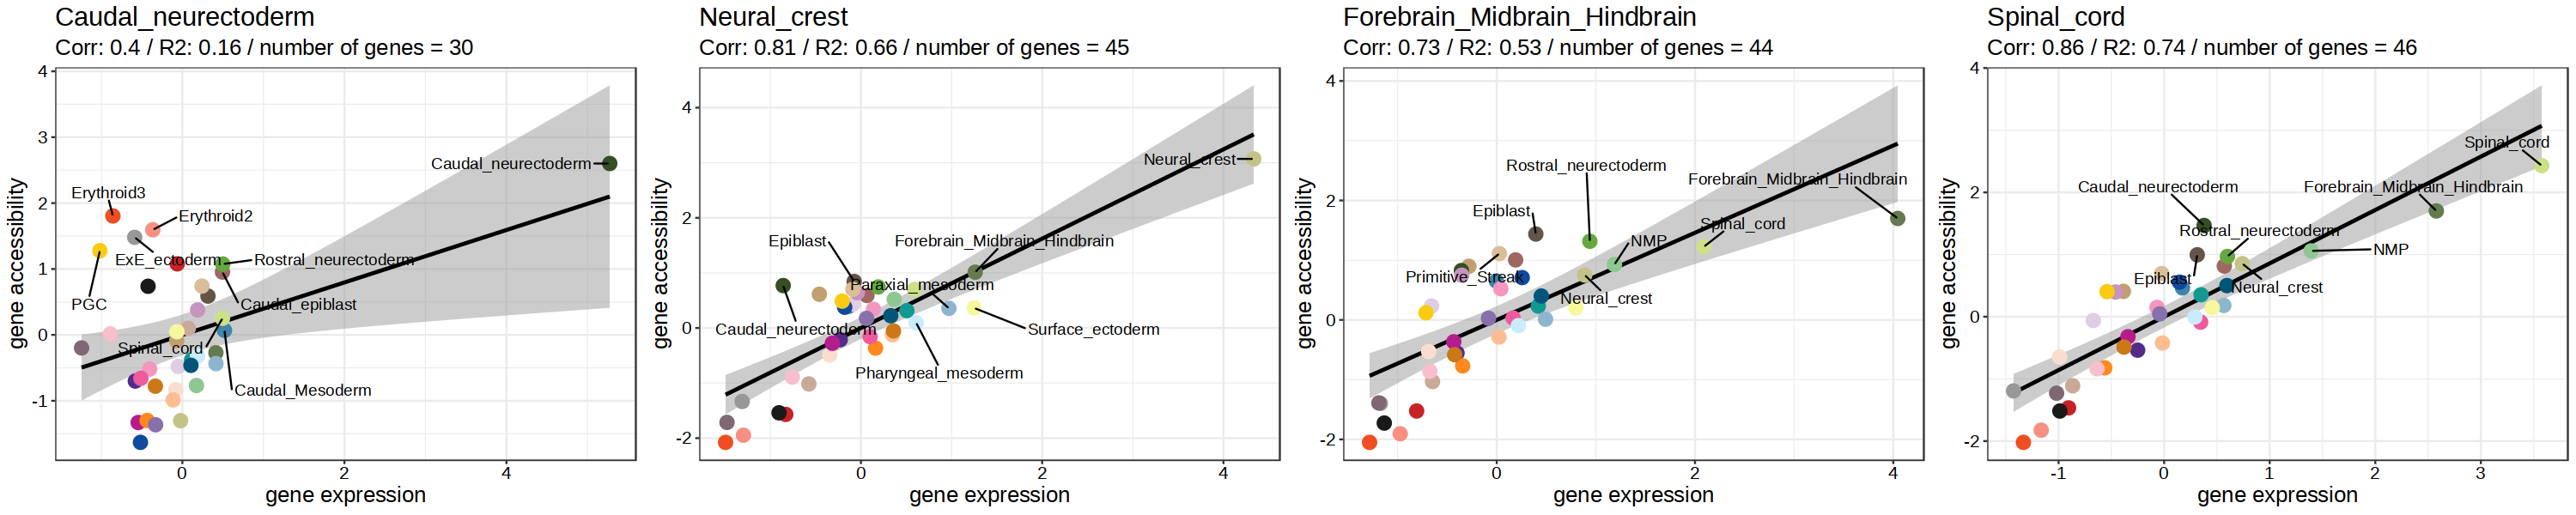

$`1`

$`2`

$`3`

$`4`

$`5`

$`6`

$`7`

$`8`

$`9`

$`10`

attr(,"class")
[1] "list"      "ggarrange"

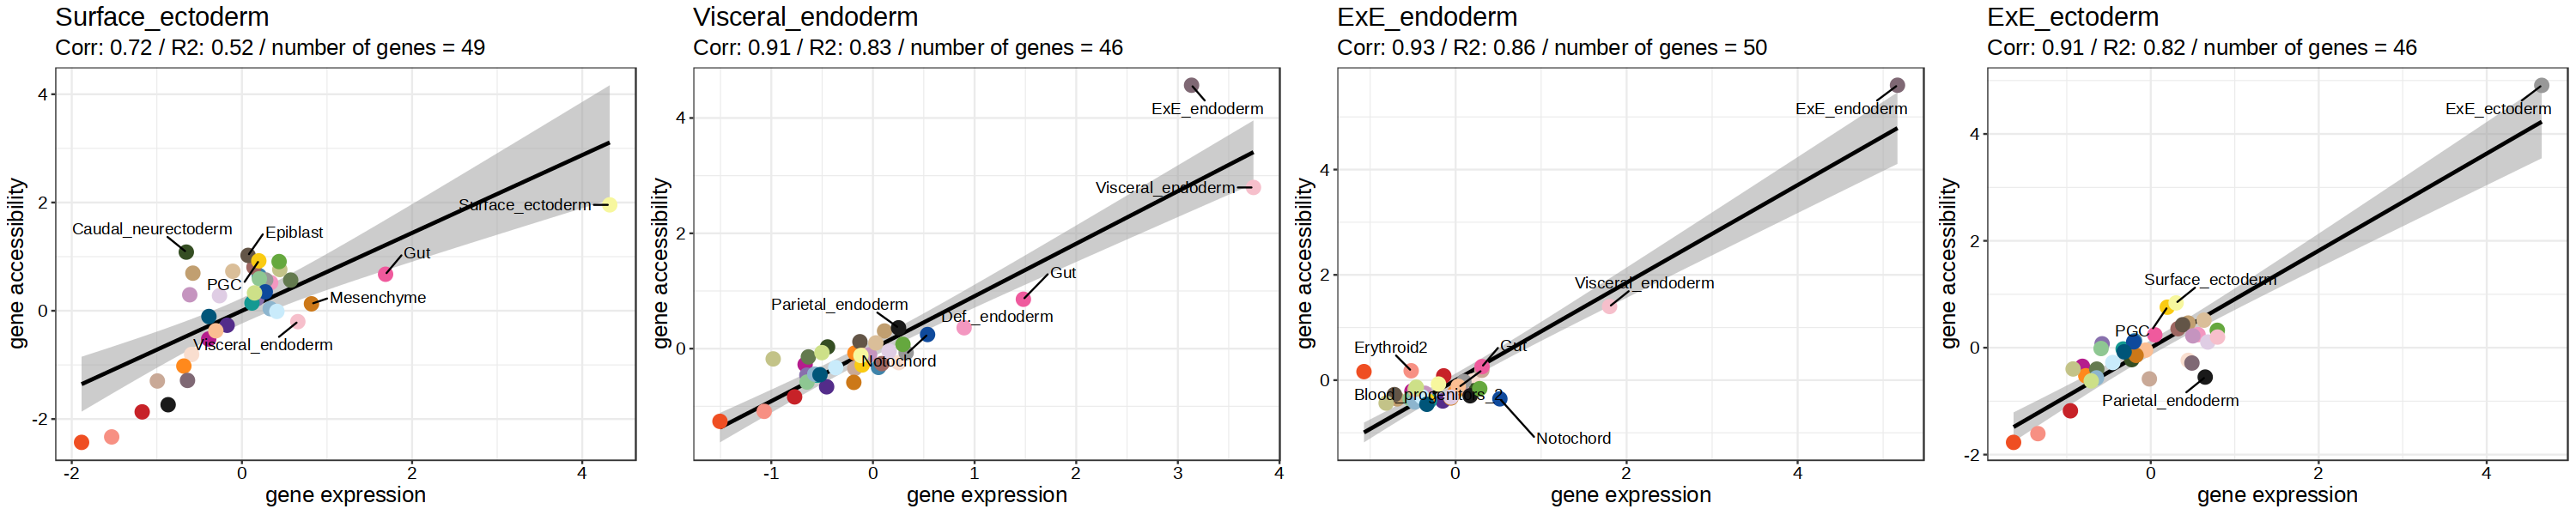

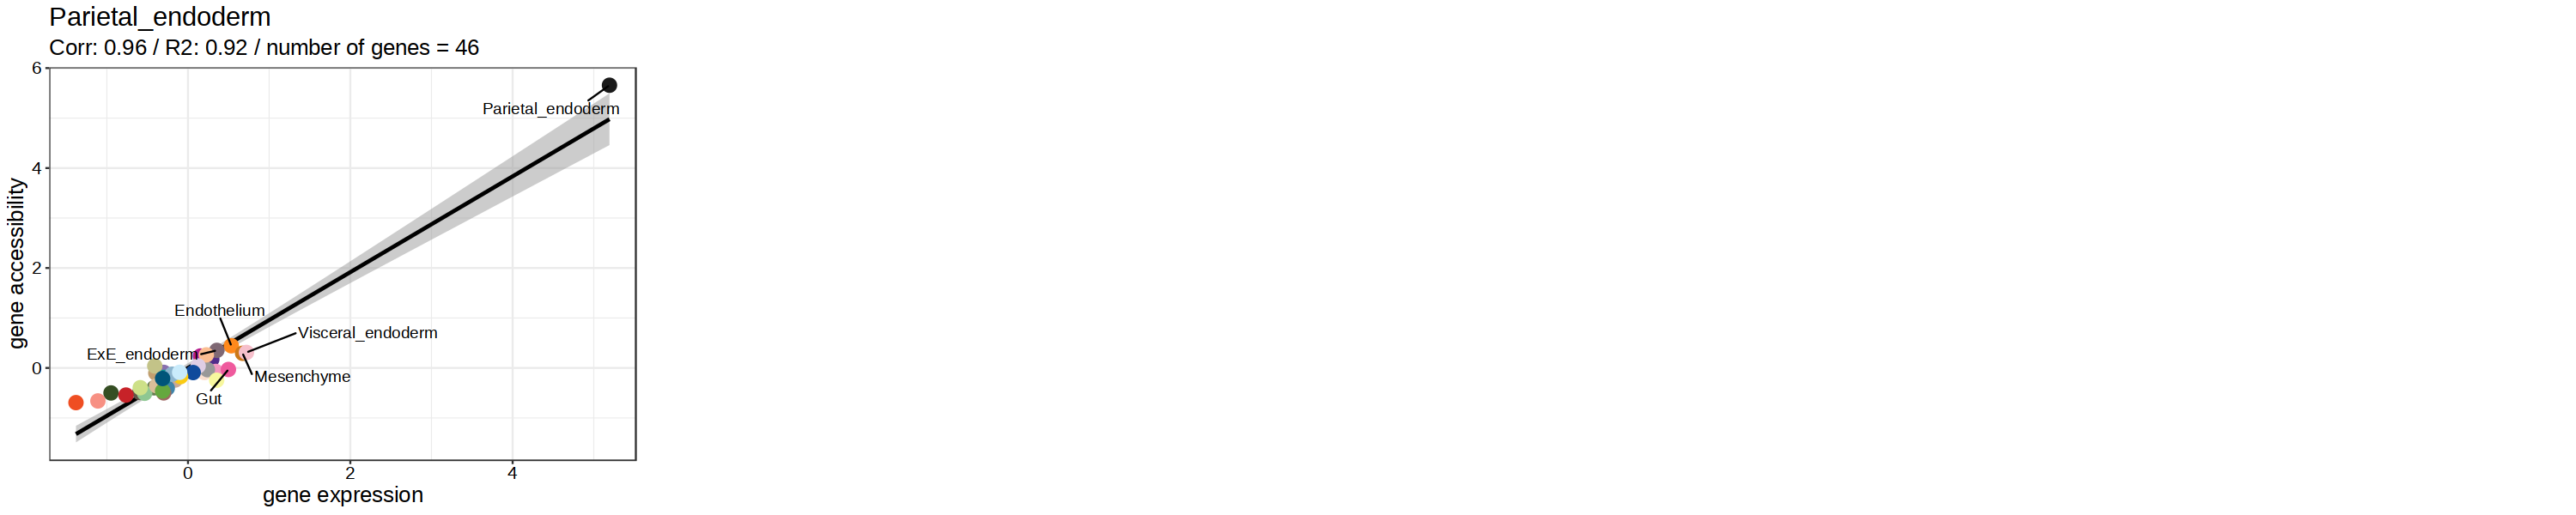

In [67]:
ggarrange(plotlist=p, ncol=4)

In [70]:
unique(markers$celltype)

[1] "Epiblast"                       "Primitive_Streak"              
 [3] "Caudal_epiblast"                "PGC"                           
 [5] "Anterior_Primitive_Streak"      "Notochord"                     
 [7] "Def._endoderm"                  "Gut"                           
 [9] "Nascent_mesoderm"               "Mixed_mesoderm"                
[11] "Intermediate_mesoderm"          "Caudal_Mesoderm"               
[13] "Paraxial_mesoderm"              "Somitic_mesoderm"              
[15] "Pharyngeal_mesoderm"            "Cardiomyocytes"                
[17] "Allantois"                      "ExE_mesoderm"                  
[19] "Mesenchyme"                     "Haematoendothelial_progenitors"
[21] "Endothelium"                    "Blood_progenitors_1"           
[23] "Blood_progenitors_2"            "Erythroid1"                    
[25] "Erythroid2"                     "Erythroid3"                    
[27] "NMP"                            "Rostral_neurectoderm"          
[29] "Caudal_neurectoderm"            "Neural_crest"                  
[31] "Forebrain_Midbrain_Hindbrain"   "Spinal_cord"                   
[33] "Surface_ectoderm"               "Visceral_endoderm"             
[35] "ExE_endoderm"                   "ExE_ectoderm"                  
[37] "Parietal_endoderm"

In [71]:
# Plot mean of celltype markers_tmp
options(repr.plot.width=25, repr.plot.height=5)

p = lapply(c('Cardiomyocytes', 'Endothelium','Gut','Neural_crest'), function(x){
        markers_tmp = markers[celltype==x] %>% 
            .[order(-score), gene] %>% head(50)
        markers_tmp = Reduce(intersect, list(markers_tmp, rownames(atac.mtx), rownames(rna.mtx)))

        if(length(markers_tmp)>1){
            rna.tmp = data.table(celltype = colnames(rna.mtx), rna_counts = colMeans(rna.mtx[markers_tmp,]))
            atac.tmp =  data.table(celltype = colnames(atac.mtx), atac_counts = colMeans(atac.mtx[markers_tmp,]))

            merge = merge(rna.tmp, atac.tmp, by='celltype') %>%
                .[,`:=`(rna_counts = scale(rna_counts),
                        atac_counts = scale(atac_counts))]

    #        options(repr.plot.width=6, repr.plot.height=6)
            
            lm = lm(rna_counts ~ atac_counts, merge)

            ggplot(merge, aes(rna_counts, atac_counts)) + 
                geom_smooth(method='lm', col='black', alpha=0.5) + 
                geom_point(size=4, aes(col=celltype)) + 
            #    geom_abline(slope=1) + 
                scale_colour_manual(values=opts$celltype.colors) + 
                ggrepel::geom_text_repel(data=unique(rbind(head(merge[order(-rna_counts)], 5), head(merge[order(-atac_counts)], 5))), # label top 5 of atac & rna
                                         aes(label=celltype),
                                         box.padding=0.8) + 
                ggtitle(x,
                       paste('Corr:', round(cor(merge$rna_counts, merge$atac_counts, method='pearson'),2), 
                             '/ R2:', round(summary(lm)$r.squared,2), 
                             '/ number of genes =', length(markers_tmp))) + 
                xlab('gene expression') + ylab('gene accessibility') + 
                theme_bw() +
                theme(legend.position='none',
                      text=element_text(size=15, color='black'),
                      axis.text=element_text(color='black'))
    }
})

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

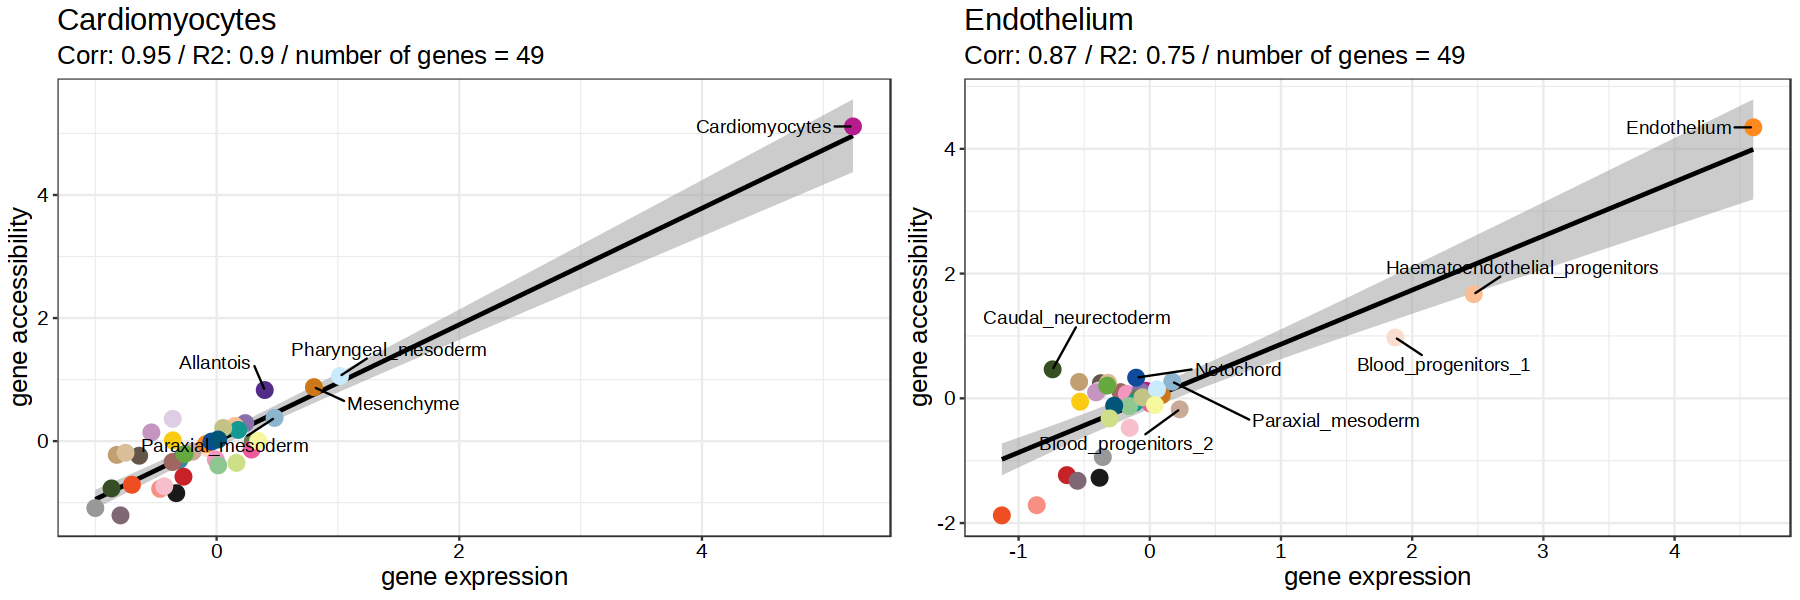

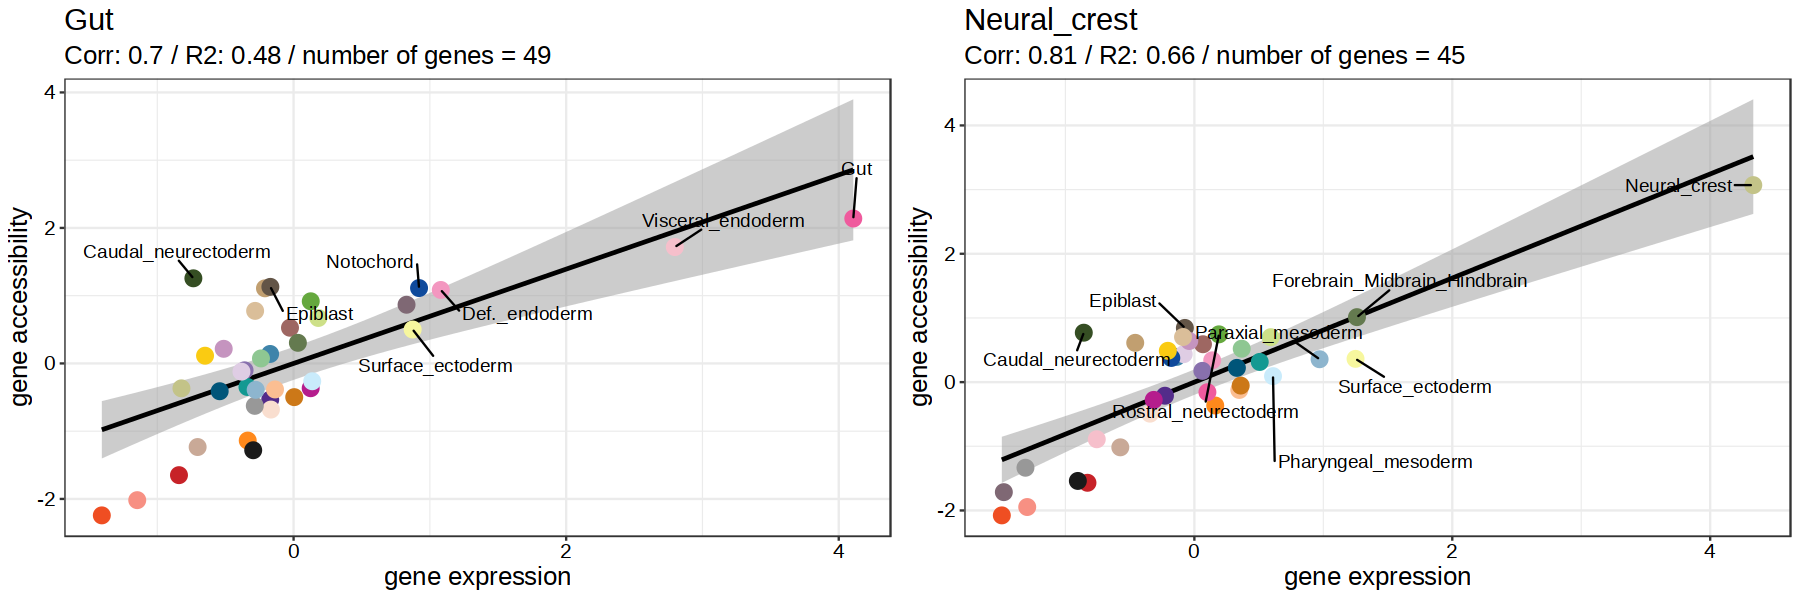

In [74]:
options(repr.plot.width=15, repr.plot.height=5)
ggarrange(plotlist=p, ncol=2)